[Escenario A] Amplitud: pasos=34, visitados=11, camino=8
  Secuencia: [None, 'down', 'down', 'right', 'right', 'right', 'right', 'down']

[Escenario A] Profundidad: pasos=28, visitados=9, camino=8
  Secuencia: [None, 'down', 'down', 'right', 'right', 'right', 'right', 'down']

[Escenario A] Costo uniforme: pasos=34, visitados=11, camino=8
  Secuencia: [None, 'down', 'down', 'right', 'right', 'right', 'right', 'down']

[Escenario A] Greedy: pasos=28, visitados=9, camino=8
  Secuencia: [None, 'down', 'down', 'right', 'right', 'right', 'right', 'down']

[Escenario A] A* Manhattan: pasos=31, visitados=10, camino=8
  Secuencia: [None, 'down', 'down', 'right', 'right', 'right', 'right', 'down']

[Escenario A] A* Euclidean: pasos=31, visitados=10, camino=8
  Secuencia: [None, 'down', 'down', 'right', 'right', 'right', 'right', 'down']

[Escenario B] Amplitud: pasos=49, visitados=16, camino=12
  Secuencia: [None, 'down', 'down', 'right', 'right', 'down', 'right', 'right', 'up', 'right', 'right

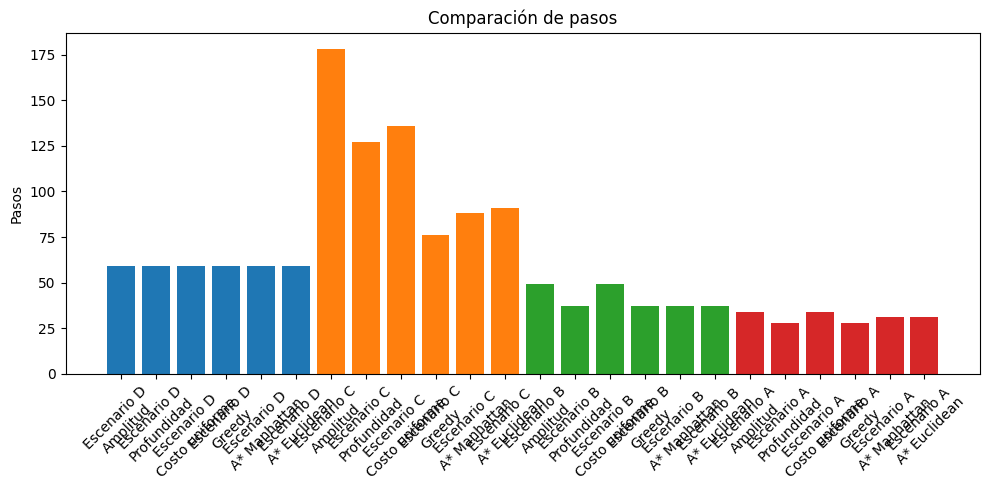

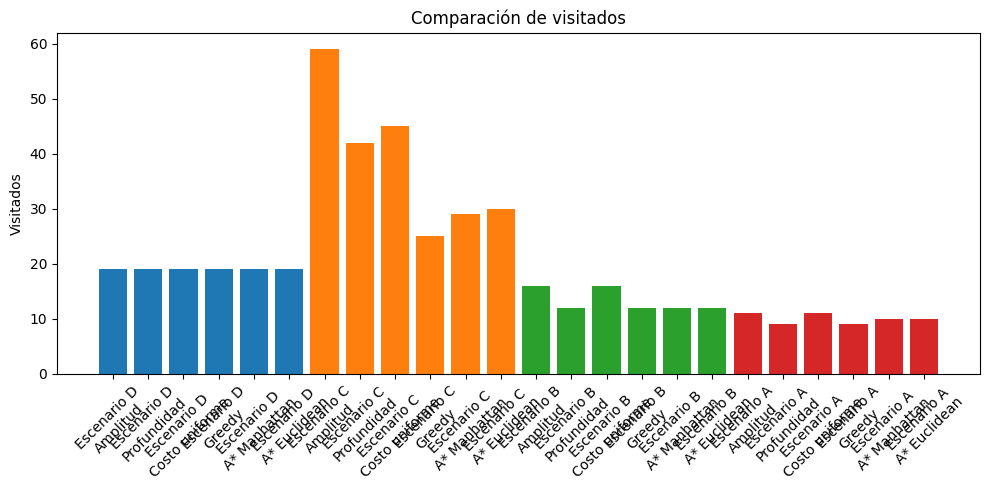

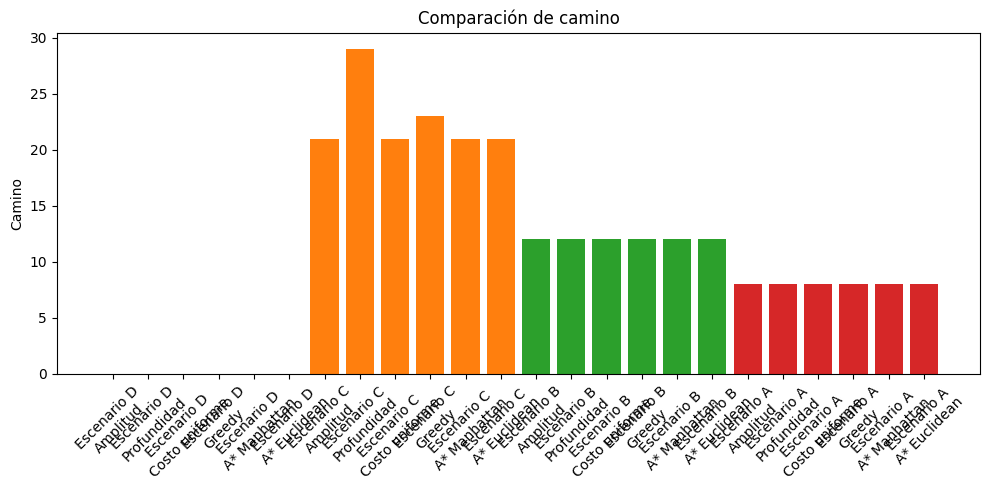

In [ ]:
#Codigo creado por el grupo F, conformado por
#- Luis Jose Gonzalez Montilla 2024-0509
#- Carlos Jose Gonzalez Brea 2023-1693
#- Eimy Karolina Genao Garcia 2024-0543
#- Esmerandy Diaz 2024-0979
!pip install simpleai --quiet

# Importaciones y librerias
from simpleai.search import SearchProblem, astar, breadth_first, greedy, depth_first, uniform_cost
from simpleai.search.viewers import BaseViewer
import matplotlib.pyplot as plt
import math
import csv

# Mapas de escenarios
TEXT_MAP_A = """
#######
#S #  #
# ### #
#     #
### #G#
#######
"""

TEXT_MAP_B = """
#########
#S#     #
# ### ###
#   #   #
###   #G#
#########
"""

TEXT_MAP_C = """
#############
#S#       # #
# # ##### # #
# #     #   #
# ### # ### #
#     #     #
### ### ### #
#       #   #
##### #   ###
#   #   #   #
# # ##### # #
# #       #G#
#############
"""

TEXT_MAP_D = """
###########
#    #    #
# ##   ## #
#  #S#   #G
###########
"""

# Costos de movimientos
COSTS_EQUAL = {'up': 1, 'down': 1, 'left': 1, 'right': 1}
COSTS_UP_EXPENSIVE = {'up': 3, 'down': 1, 'left': 1, 'right': 1}

# Conversion de mapa a matriz
def text_map_to_grid(text_map):
    return [list(line) for line in text_map.strip().splitlines()]

# Definicion del problema
class DeliveryProblem(SearchProblem):
    def __init__(self, map_text, movement_costs, heuristic_type='manhattan'):
        self.grid = text_map_to_grid(map_text)
        self.height = len(self.grid)
        self.width = len(self.grid[0])
        self.costs = movement_costs
        self.heuristic_type = heuristic_type

        for y, row in enumerate(self.grid):
            for x, cell in enumerate(row):
                if cell == 'S':
                    self.initial = (x, y)
                elif cell == 'G':
                    self.goal = (x, y)

        super().__init__(initial_state=self.initial)

    def actions(self, state):
        actions = []
        x, y = state
        directions = {
            'up': (x, y - 1),
            'down': (x, y + 1),
            'left': (x - 1, y),
            'right': (x + 1, y),
        }
        for action, (nx, ny) in directions.items():
            if 0 <= nx < self.width and 0 <= ny < self.height:
                if self.grid[ny][nx] != '#':
                    actions.append(action)
        return actions

    def result(self, state, action):
        x, y = state
        return {
            'up': (x, y - 1),
            'down': (x, y + 1),
            'left': (x - 1, y),
            'right': (x + 1, y)
        }[action]

    def is_goal(self, state):
        return state == self.goal

    def cost(self, state1, action, state2):
        return self.costs[action]

    def heuristic(self, state):
        x1, y1 = state
        x2, y2 = self.goal
        if self.heuristic_type == 'manhattan':
            return abs(x1 - x2) + abs(y1 - y2)
        elif self.heuristic_type == 'euclidean':
            return math.sqrt((x1 - x2) ** 2 + (y1 - y2) ** 2)
        return 0

# Visor para contar pasos y visitados
class MyViewer(BaseViewer):
    def __init__(self):
        self.steps = 0
        self.visited = set()

    def event(self, event_name, node=None, *args):
        self.steps += 1
        if node and hasattr(node, 'state'):
            self.visited.add(node.state)

# Algoritmos basicos
def get_algorithms(problem):
    return [
        ('Amplitud', lambda v: breadth_first(problem, graph_search=True, viewer=v)),
        ('Profundidad', lambda v: depth_first(problem, graph_search=True, viewer=v)),
        ('Costo uniforme', lambda v: uniform_cost(problem, graph_search=True, viewer=v)),
        ('Greedy', lambda v: greedy(problem, graph_search=True, viewer=v)),
    ]

# EXPERIMENTO INDIVIDUAL POR ESCENARIO ---
def run_experiment(name, map_text, movement_costs):
    results = []

    # Parte 1: Algoritmos clásicos
    base_problem = DeliveryProblem(map_text, movement_costs)
    algorithms = get_algorithms(base_problem)

    for algo_name, algo_func in algorithms:
        viewer = MyViewer()
        result = algo_func(viewer)
        path = result.path() if result else []
        steps = viewer.steps
        visited = len(viewer.visited)
        path_len = len(path)
        actions = [action for action, state in path]

        print(f"[{name}] {algo_name}: pasos={steps}, visitados={visited}, camino={path_len}")
        print(f"  Secuencia: {actions}\n")

        results.append({
            'escenario': name,
            'algoritmo': algo_name,
            'pasos': steps,
            'visitados': visited,
            'camino': path_len,
            'acciones': actions
        })

    # Parte 2: A* con heurísticas Manhattan y Euclídea
    for h_type in ['manhattan', 'euclidean']:
        problem_astar = DeliveryProblem(map_text, movement_costs, heuristic_type=h_type)
        viewer = MyViewer()
        result = astar(problem_astar, graph_search=True, viewer=viewer)
        path = result.path() if result else []
        steps = viewer.steps
        visited = len(viewer.visited)
        path_len = len(path)
        actions = [action for action, state in path]

        nombre_algoritmo = f"A* {h_type.capitalize()}"
        print(f"[{name}] {nombre_algoritmo}: pasos={steps}, visitados={visited}, camino={path_len}")
        print(f"  Secuencia: {actions}\n")

        results.append({
            'escenario': name,
            'algoritmo': nombre_algoritmo,
            'pasos': steps,
            'visitados': visited,
            'camino': path_len,
            'acciones': actions
        })

    return results

# Vizualizar resultados
def plot_results(results):
    medidas = ['pasos', 'visitados', 'camino']
    escenarios = list(set(r['escenario'] for r in results))

    for medida in medidas:
        plt.figure(figsize=(10, 5))
        for escenario in escenarios:
            datos = [r for r in results if r['escenario'] == escenario]
            nombres = [r['algoritmo'] for r in datos]
            valores = [r[medida] for r in datos]
            plt.bar([f"{escenario}\n{n}" for n in nombres], valores)
        plt.title(f"Comparación de {medida}")
        plt.xticks(rotation=45)
        plt.ylabel(medida.capitalize())
        plt.tight_layout()
        plt.show()

# Ejecucion de los escenarios
results = []
results += run_experiment("Escenario A", TEXT_MAP_A, COSTS_EQUAL)
results += run_experiment("Escenario B", TEXT_MAP_B, COSTS_EQUAL)
results += run_experiment("Escenario C", TEXT_MAP_C, COSTS_UP_EXPENSIVE)
results += run_experiment("Escenario D", TEXT_MAP_D, COSTS_EQUAL)

# Muestra de graficos
plot_results(results)
